In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from pathlib import Path
import re

def analyze_parquet_files(path):
  """Prints folder names and file number ranges for Parquet files in a directory.

  Args:
    path: The path to the directory containing the folders.
  """
  for folder in path.iterdir():
    if folder.is_dir():
      print(f"Folder: {folder.name}")
      file_numbers = []
      for file in folder.glob("*.parquet"):
        match = re.search(r"_(\d+)\.parquet", file.name)
        if match:
          file_numbers.append(int(match.group(1)))
      if file_numbers:
        print(f"  File Name Pattern: {file.name.split('_')[0]}_*.parquet")
        print(f"  File Number Range: {min(file_numbers)} - {max(file_numbers)}")
      else:
        print("  No matching Parquet files found.")

# Example usage:
# path = Path('/groups/pheno/inar/icecube_ice_public_parquet')
path = Path('/groups/pheno/inar/water_icecube')
analyze_parquet_files(path)

Folder: pulses
  File Name Pattern: pulses_*.parquet
  File Number Range: 803 - 818
Folder: pulses_no_noise
  File Name Pattern: pulses_*.parquet
  File Number Range: 699 - 818
Folder: selections
  No matching Parquet files found.
Folder: merged_photons
  File Name Pattern: merged_*.parquet
  File Number Range: 0 - 698
Folder: mc_truth
  File Name Pattern: mc_*.parquet
  File Number Range: 0 - 818


In [4]:
df = pd.read_parquet(path  / 'mc_truth/mc_truth_806.parquet', engine='pyarrow')
df.head()

,interaction,initial_state_energy,initial_state_type,initial_state_zenith,initial_state_azimuth,initial_state_x,initial_state_y,initial_state_z,bjorken_x,bjorken_y,visible_inelasticity,muon_azimuth,muon_zenith
event_no,,,,,,,,,,,,,
4747480,1,32383.640519,14,1.473054,5.825106,-459.875563,-377.662285,-1447.117559,0.215307,0.485792,0.454519,5.827324,1.470423
17252720,1,2261.599481,14,0.775109,2.816342,-48.418190,-469.724378,-1734.340631,0.061902,0.193283,0.159535,2.819789,0.772558
837708,1,31546.326496,14,0.229271,2.697784,-64.037805,-512.441717,-2029.588283,0.026915,0.188984,0.167340,2.698411,0.229865
3134819,1,47.456417,14,0.584034,0.942614,-358.506784,188.436694,-1718.362437,0.193109,0.577787,0.481432,0.815592,0.505673
19415486,2,5998.272055,14,0.833488,1.684179,-162.989737,-4.129040,-2127.412161,0.042269,0.832457,1.000000,-1.000000,-1.000000


In [5]:
df

,interaction,initial_state_energy,initial_state_type,initial_state_zenith,initial_state_azimuth,initial_state_x,initial_state_y,initial_state_z,bjorken_x,bjorken_y,visible_inelasticity,muon_azimuth,muon_zenith
event_no,,,,,,,,,,,,,
4747480,1,32383.640519,14,1.473054,5.825106,-459.875563,-377.662285,-1447.117559,0.215307,0.485792,0.454519,5.827324,1.470423
17252720,1,2261.599481,14,0.775109,2.816342,-48.418190,-469.724378,-1734.340631,0.061902,0.193283,0.159535,2.819789,0.772558
837708,1,31546.326496,14,0.229271,2.697784,-64.037805,-512.441717,-2029.588283,0.026915,0.188984,0.167340,2.698411,0.229865
3134819,1,47.456417,14,0.584034,0.942614,-358.506784,188.436694,-1718.362437,0.193109,0.577787,0.481432,0.815592,0.505673
19415486,2,5998.272055,14,0.833488,1.684179,-162.989737,-4.129040,-2127.412161,0.042269,0.832457,1.000000,-1.000000,-1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14824198,2,117.206284,14,0.872859,1.512383,-195.099185,468.277989,-1513.203383,0.054663,0.743497,1.000000,-1.000000,-1.000000
18885691,2,63058.343584,14,1.790164,4.600472,-0.405519,600.461735,-2172.415811,0.168980,0.065423,1.000000,-1.000000,-1.000000
12835520,2,18346.185093,14,2.338121,3.083058,513.890905,-288.263810,-2268.059449,0.094612,0.093989,1.000000,-1.000000,-1.000000


Text(0.5, 0, 'initial state energy (GeV)')

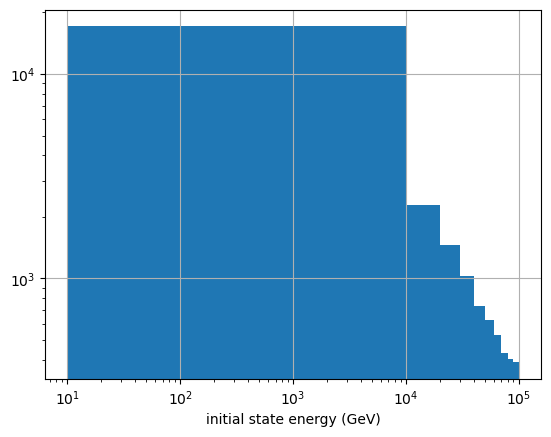

In [6]:
plt.figure()
df.initial_state_energy.hist()
plt.xscale('log')
plt.yscale('log')
plt.xlabel('initial state energy (GeV)')

In [7]:
df1 = pd.read_parquet(path  / 'pulses/pulses_806.parquet', engine='pyarrow')
df1.head()

,sensor_pos_x,sensor_pos_y,sensor_pos_z,t,string_id,is_signal,charge
event_no,,,,,,,
4747480,124.97,-131.25,-1794.83,16.297433,27,0.0,0.920523
4747480,-189.98,257.42,-1633.94,39.154359,62,0.0,0.783249
4747480,101.04,412.79,-2294.69,90.391105,72,0.0,1.029806
4747480,-132.80,-501.45,-2350.10,115.543278,2,0.0,0.857138
4747480,405.83,-306.38,-2423.12,115.780866,13,0.0,0.958461


In [8]:
df1.describe()

,sensor_pos_x,sensor_pos_y,sensor_pos_z,t,string_id,is_signal,charge
count,1.277501e+07,1.277501e+07,1.277501e+07,1.277501e+07,1.277501e+07,1.277501e+07,1.277501e+07
mean,5.337055e+00,-2.333811e+00,-1.979954e+03,2.294363e+03,4.308215e+01,6.220940e-01,6.967675e+00
std,2.783369e+02,2.661007e+02,2.909426e+02,8.914329e+02,2.475323e+01,4.848550e-01,7.171188e+02
min,-5.709000e+02,-5.210800e+02,-2.460890e+03,3.149097e-04,0.000000e+00,0.000000e+00,8.704501e-05
25%,-2.113500e+02,-2.090700e+02,-2.232600e+03,1.914864e+03,2.200000e+01,0.000000e+00,8.635968e-01
50%,1.187000e+01,-1.560000e+01,-1.992720e+03,2.528535e+03,4.300000e+01,1.000000e+00,1.053749e+00
75%,2.104700e+02,2.116600e+02,-1.735940e+03,2.855684e+03,6.400000e+01,1.000000e+00,1.290428e+00
max,5.763700e+02,5.095000e+02,-1.423510e+03,6.367751e+03,8.600000e+01,1.000000e+00,7.456809e+05


In [7]:
df1.sensor_pos_x.array

<NumpyExtensionArray>
[              np.float64(85.41),              np.float64(-41.85),
               np.float64(-1.63),               np.float64(-28.6),
               np.float64(38.17),                np.float64(8.54),
              np.float64(-56.11),                np.float64(38.5),
                np.float64(9.07),               np.float64(38.17),
 ...
              np.float64(-45.84),              np.float64(-23.16),
              np.float64(-23.16),              np.float64(-23.16),
              np.float64(-21.61),              np.float64(-13.75),
              np.float64(-13.34), np.float64(-13.339999999999995),
 np.float64(-13.340000000000002),                np.float64(0.88)]
Length: 113187267, dtype: float64

In [ ]:
plt.scatter(df1.sensor_pos_x, df1.sensor_pos_y)

In [8]:
import pandas as pd
# Assuming df has columns 'sensor_pos_x', 'sensor_pos_y', 'sensor_pos_z'
precision = 2 # Adjust as needed based on ORCA DOM spacing
df_rounded_coords = df1[['sensor_pos_x', 'sensor_pos_y', 'sensor_pos_z']].round(decimals=precision)
# Add string_id if available and relevant for unique identification
df_rounded_coords['string_id'] = df1['string_id']

In [10]:
df_rounded_coords.sensor_pos_x.unique()

array([ 85.41, -41.85,  -1.63, -28.6 ,  38.17,   8.54, -56.11,  38.5 ,
         9.07, -56.81, -72.44,  77.16,  63.89,  68.33, -26.71,   0.24,
        32.17,  -9.23, -97.78,  60.68, -70.93,  47.33, -69.39,  50.98,
        20.64, -23.16, -50.02, -45.84, -58.21, -73.23, -32.73,  -5.  ,
        80.01,  -4.28,  90.23,  -2.44,  24.33,  65.82, -15.12, -24.08,
       -18.27,  -1.25, -84.09, -47.6 , -23.22, -12.  ,  24.51, -19.7 ,
       -13.34,  33.31, -13.75, -27.84, -52.21,  19.43, -57.87,  80.46,
        58.88,  46.11, -82.32, -45.61, -21.61, -42.13,  66.5 ,  37.62,
       -50.04, -55.56,  91.15,   7.8 ,  76.56,  44.24, -31.46,  10.72,
        47.07,  18.81,   4.37,  16.34, -16.31,  16.61, -47.13,  58.11,
         0.88,  78.51,  -4.02,  80.15,  21.11, -31.23,  51.98, -32.59,
       -78.11,  -6.83,  38.78,  72.  ,  24.7 ,   6.64, -61.17,  65.57,
        30.02, -68.48, -69.22,  36.82,   7.89,  18.05,  50.35,  14.69,
       -74.02, -36.99, -59.78, -32.05,  32.88,   7.96, -84.06,  19.78,
      

In [11]:
unique_doms_df = df_rounded_coords.drop_duplicates().reset_index(drop=True)

In [12]:
unique_doms_df

,sensor_pos_x,sensor_pos_y,sensor_pos_z,string_id
0,85.41,-52.02,154.53,148.0
1,-41.85,53.49,127.26,68.0
2,-1.63,35.26,127.26,18.0
3,-28.60,48.79,190.89,47.0
4,38.17,-44.84,109.08,51.0
...,...,...,...,...
3295,-16.31,38.97,63.63,26.0
3296,44.24,-61.64,45.45,85.0
3297,-73.89,33.27,90.90,97.0
3298,-9.23,50.74,127.26,39.0


In [16]:
len(df_rounded_coords.string_id.unique())

150

In [17]:
3300/150

22.0

In [ ]:

# Assuming 'unique_doms_df' is your DataFrame as shown in the image

# Example: Sort by string_id (ascending), then by sensor_pos_z (descending - deeper DOMs first)
# Adjust ascending=[True, False] as per ORCA's DOM numbering convention
unique_doms_df_sorted = unique_doms_df.sort_values(
    by=['string_id', 'sensor_pos_z'],
    ascending=[True, False] # True for ascending string_id, False for descending z
).reset_index(drop=True)

# After sorting, you can assign the sensor_id based on the new sorted order
unique_doms_df_sorted['sensor_id'] = unique_doms_df_sorted.index

# Now, 'unique_doms_df_sorted' is ready to be saved as your sensor_geometry.csv
# Select and rename columns if necessary to match the expected format for SensorMapping
# e.g., sensor_pos_x -> x, sensor_pos_y -> y, sensor_pos_z -> z
final_geometry_df = unique_doms_df_sorted.rename(columns={
    'sensor_pos_x': 'x',
    'sensor_pos_y': 'y',
    'sensor_pos_z': 'z'
})

# Ensure you have the 'sensor_id', 'x', 'y', 'z' columns as a minimum
# You might want to keep 'string_id' in the final CSV for reference too.
# final_geometry_df = final_geometry_df[['sensor_id', 'x', 'y', 'z', 'string_id']] # Reorder/select columns

print("Sorted unique DOMs DataFrame head:")
print(final_geometry_df.head())


Sorted unique DOMs DataFrame head:
      x     y       z  string_id  sensor_id
0 -4.28  3.92  190.89        0.0          0
1 -4.28  3.92  181.80        0.0          1
2 -4.28  3.92  172.71        0.0          2
3 -4.28  3.92  163.62        0.0          3
4 -4.28  3.92  154.53        0.0          4


In [20]:

# Example of saving:
final_geometry_df.to_csv(path  / 'orca_sensor_geometry.csv', index=False)

In [24]:
import pandas as pd
from pathlib import Path

# Assume 'unique_doms_df' is your DataFrame after finding unique DOM positions
# from your Prometheus ORCA data. It should have columns like:
# 'sensor_pos_x', 'sensor_pos_y', 'sensor_pos_z', and 'string_id' (if available and used for sorting)

# --- Example: This is how unique_doms_df might look (replace with your actual DataFrame) ---
# data = {
# 'sensor_pos_x': [85.41, -41.85, -1.63, -28.60, 38.17],
# 'sensor_pos_y': [-52.02, 53.49, 35.26, 48.79, -44.84],
# 'sensor_pos_z': [154.53, 127.26, 127.26, 190.89, 109.08],
# 'string_id': [148.0, 68.0, 18.0, 47.0, 51.0] # Example, if you have it
# }
# unique_doms_df = pd.DataFrame(data)
# ------------------------------------------------------------------------------------------

# 1. Sort the DataFrame to establish a canonical order for DOMs.
# The index after sorting and resetting will become your 0-indexed sensor_id.
unique_doms_df_sorted = unique_doms_df.sort_values(
    by=['string_id', 'sensor_pos_z'], # Adjust sorting criteria as needed for ORCA
    ascending=[True, True]           # Adjust ascending/descending as per ORCA convention
).reset_index(drop=True)

# 2. Create the explicit 'sensor_id' column from the new 0-indexed DataFrame index.
unique_doms_df_sorted['sensor_id'] = unique_doms_df_sorted.index

# 3. Rename coordinate columns to the standard 'x', 'y', 'z'.
geometry_to_save = unique_doms_df_sorted.rename(columns={
    'sensor_pos_x': 'x',
    'sensor_pos_y': 'y',
    'sensor_pos_z': 'z'
    # 'string_id' column can be kept if you want it in the final CSV for reference
})

# 4. Select the columns for the final CSV file in the desired order: sensor_id,x,y,z
# This matches the IceCube format you provided.
output_columns = ['sensor_id', 'x', 'y', 'z']

# If you also want to include 'string_id' for reference (though not in the strict IceCube example):
# output_columns = ['sensor_id', 'x', 'y', 'z', 'string_id']

final_orca_geometry_df = geometry_to_save[output_columns]

# 5. Define the output path and save the CSV.
output_dir = Path('/groups/pheno/inar/orca_prometheus') # Your specified path
output_dir.mkdir(parents=True, exist_ok=True) # Ensure directory exists
output_csv_path = output_dir / 'orca_sensor_geometry.csv' # New name to avoid overwrite

# Save to CSV:
# - index=False: Prevents pandas from writing its current DataFrame index as another column.
# - header=True: Includes the column names (sensor_id,x,y,z) as the first line.
final_orca_geometry_df.to_csv(output_csv_path, index=False, header=True)

print(f"Sorted ORCA sensor geometry with explicit 'sensor_id' saved to: {output_csv_path}")
print("Head of the saved geometry file content:")
print(final_orca_geometry_df.head().to_string())

Sorted ORCA sensor geometry with explicit 'sensor_id' saved to: /groups/pheno/inar/orca_prometheus/orca_sensor_geometry.csv
Head of the saved geometry file content:
   sensor_id     x     y      z
0          0 -4.28  3.92   0.00
1          1 -4.28  3.92   9.09
2          2 -4.28  3.92  18.18
3          3 -4.28  3.92  27.27
4          4 -4.28  3.92  36.36
